Given a node in a connected undirected graph, return a deep copy of the graph.

Each node in the graph contains an integer value and a list of its neighbors.

class Node {
    public int val;
    public List<Node> neighbors;
}

The graph is shown in the test cases as an adjacency list. An adjacency list is a mapping of nodes to lists, used to represent a finite graph. Each list describes the set of neighbors of a node in the graph.

For simplicity, nodes values are numbered from 1 to n, where n is the total number of nodes in the graph. The index of each node within the adjacency list is the same as the node's value (1-indexed).

The input node will always be the first node in the graph and have 1 as the value.

Example 1:

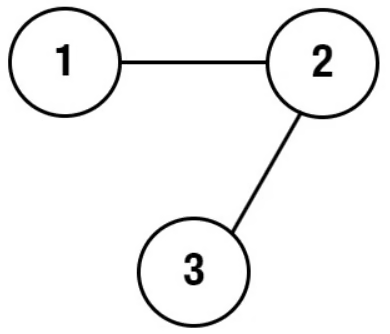

Input: adjList = [[2],[1,3],[2]]

Output: [[2],[1,3],[2]]

Explanation: There are 3 nodes in the graph.

Node 1: val = 1 and neighbors = [2].

Node 2: val = 2 and neighbors = [1, 3].

Node 3: val = 3 and neighbors = [2].

Example 2:

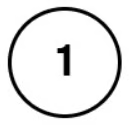

Input: adjList = [[]]

Output: [[]]

Explanation: The graph has one node with no neighbors.

Example 3:

Input: adjList = []

Output: []

Explanation: The graph is empty.

In [ ]:
from typing import Optional
from collections import deque

# DFS

Intuition

The graph may contain cycles, so we cannot simply copy nodes recursively without remembering what we've already copied.

To handle this, we use a map (old → new):

When we first see a node, we create its copy.

If we see the same node again, we reuse the already-created copy.

This avoids infinite loops and ensures each node is cloned exactly once.

Depth First Search (DFS) helps us explore and clone all connected nodes.

Algorithm

If the input node is null, return null.

Create a map to store original nodes -> cloned nodes.

Start DFS from the given node:

If the node is already in the map, return its clone.

Create a new node with the same value.

Store it in the map.

Recursively clone all neighbors and add them to the clone’s neighbor list.

Return the cloned node corresponding to the starting node.


In [ ]:
# Definition for a Node.
class Node:
    def __init__(self, val = 0, neighbors = None):
        self.val = val
        self.neighbors = neighbors if neighbors is not None else []

In [ ]:
# Time Complexity: O(V + E)
# Space Complexity: O(V)
class Solution:
    def cloneGraph(self, node: Optional['Node']) -> Optional['Node']:
        if not node:
            return None
        
        visited = {}
        
        def dfs(original_node):
            if original_node in visited:
                return visited[original_node]
            
            cloned_node = Node(original_node.val)
            visited[original_node] = cloned_node
            
            for neighbor in original_node.neighbors:
                cloned_node.neighbors.append(dfs(neighbor))
            
            return cloned_node
        
        return dfs(node)

# BFS

Intuition

The graph can have cycles, so while cloning we must avoid creating duplicate nodes or looping forever.

Using Breadth First Search (BFS), we explore the graph level by level and keep a map from original nodes to their clones.

When a node is first seen, create its clone and store it in the map.

For every neighbor, ensure its clone exists, then connect the cloned nodes.

The map guarantees each node is cloned only once.

Algorithm

If the input node is null, return null.

Create a map to store original node -> cloned node.

Initialize a queue with the starting node and create its clone.

While the queue is not empty:

Pop a node.

For each of its neighbors:

If the neighbor is not cloned yet, clone it and add it to the queue.

Add the cloned neighbor to the current node’s clone neighbor list.

Return the cloned version of the starting node.

In [ ]:
# Time Complexity: O(m × n)
# Space Complexity: O(m × n)
class Solution:
    def cloneGraph(self, node: Optional['Node']) -> Optional['Node']:
        if not node:
            return None

        oldToNew = {}
        oldToNew[node] = Node(node.val)
        q = deque([node])

        while q:
            cur = q.popleft()
            for nei in cur.neighbors:
                if nei not in oldToNew:
                    oldToNew[nei] = Node(nei.val)
                    q.append(nei)
                oldToNew[cur].neighbors.append(oldToNew[nei])

        return oldToNew[node]